In [1]:
"""
L2 minimization problem [-1,1]^d 
The following three tasks are carried out. 
1. u(x) = \Pi_{i=1}^d \sin(\frac{\pi}{2} x_i), (\omega,b) \sim S^d
2. u(x) = \sin(\1/d \sum_{i=1}^d x_i), (\omega,b) \sim S^d
3. u(x) = \sin(\1/d \sum_{i=1}^d x_i), fix \omage = 1, b \sim [-2d^0.5,2d^0.5]
"""
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import sys
from scipy.sparse import linalg
from pathlib import Path
import itertools
import sympy as sp
import math  
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 

torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)
ZERO = torch.tensor([0.]).to(device)

class model(nn.Module):
    """ ReLU k shallow neural network
    Parameters: 
    input size: input dimension
    hidden_size1 : number of hidden layers 
    num_classes: output classes 
    k: degree of relu functions
    """
    def __init__(self, input_size, hidden_size1, num_classes,k = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, num_classes,bias = False)
        self.k = k 
    def forward(self, x):
        u1 = self.fc2(F.relu(self.fc1(x))**self.k)
        return u1
    def evaluate_derivative(self, x, i):
        if self.k == 1:
            u1 = self.fc2(torch.heaviside(self.fc1(x),ZERO) * self.fc1.weight.t()[i-1:i,:] )
        else:
            u1 = self.fc2(self.k*F.relu(self.fc1(x))**(self.k-1) *self.fc1.weight.t()[i-1:i,:] )  
        return u1


## Numerical quadrature 

In [2]:
def PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order):
    """ Output the coeffients and weights for piecewise Gauss Quadrature 
    Parameters
    ----------
    x_l : float 
    left endpoint of an interval 
    
    x_r: float
    right endpoint of an interval 
    
    integration_intervals: int
    number of subintervals for integration
    
    Returns
    -------
    coef1_expand
    
    gw_expand
    
    integration_points
    """
    x,w = np.polynomial.legendre.leggauss(order)
    gx = torch.tensor(x).to(device)
    gx = gx.view(1,-1) # row vector 
    gw = torch.tensor(w).to(device)    
    gw = gw.view(-1,1) # Column vector 
    nodes = torch.linspace(x_l,x_r,Nx+1).view(-1,1).to(device) 
    coef1 = ((nodes[1:,:] - nodes[:-1,:])/2) # n by 1  
    coef2 = ((nodes[1:,:] + nodes[:-1,:])/2) # n by 1  
    coef2_expand = coef2.expand(-1,gx.size(1)) # Expand to n by p shape, -1: keep the first dimension n , expand the 2nd dim (columns)
    integration_points = coef1@gx + coef2_expand
    integration_points = integration_points.flatten().view(-1,1) # Make it a column vector
    gw_expand = torch.tile(gw,(Nx,1)) # rows: n copies of current tensor, columns: 1 copy, no change
    # Modify coef1 to be compatible with func_values
    coef1_expand = coef1.expand(coef1.size(0),gx.size(1))    
    coef1_expand = coef1_expand.flatten().view(-1,1)

    return coef1_expand.to(device)*gw_expand.to(device), integration_points.to(device)

def PiecewiseGQ2D_weights_points(Nx, order,bl = [-1,-1],ur = [1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    Allows a symmetric square domain (around 0) with lower left corner at bl and upper right corner at ur 
    ----------
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """
#     print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,indexing='ij')).reshape(2,-1).T
    weights =  (w*w[:,None]).ravel()

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**2,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**2 /4 

    integration_points = torch.tile(gauss_pts,(Nx**2,1))
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(2,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**2)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,2)
    # print(ordered_pairs)
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 
#     print(integration_points.size())
    # func_values = integrand2_torch(integration_points)
    return long_weights.to(device), integration_points.to(device)


def PiecewiseGQ3D_weights_points(Nx, order,bl = [-1,-1,-1],ur = [1,1,1]): 
    """ A slight modification of PiecewiseGQ2D function that only needs the weights and integration points.
    Parameters
    ----------

    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature

    Returns
    -------
    long_weights: torch.tensor
    integration_points: torch.tensor
    """

    """
    Parameters
    ----------
    target : 
        Target function 
    Nx: int 
        number of intervals along the dimension. No Ny, assume Nx = Ny
    order: int 
        order of the Gauss Quadrature
    """

    # print("order: ",order )
    x, w = np.polynomial.legendre.leggauss(order)
    gauss_pts = np.array(np.meshgrid(x,x,x,indexing='ij')).reshape(3,-1).T
    weight_list = np.array(np.meshgrid(w,w,w,indexing='ij'))
    weights =   (weight_list[0]*weight_list[1]*weight_list[2]).ravel() 

    gauss_pts =torch.tensor(gauss_pts)
    weights = torch.tensor(weights)

    # h = 1/Nx # 100 intervals 
    h = (ur[0]- bl[0])/Nx # 100 intervals 
    long_weights =  torch.tile(weights,(Nx**3,1))
    long_weights = long_weights.reshape(-1,1)
    long_weights = long_weights * h**3 /8 

    integration_points = torch.tile(gauss_pts,(Nx**3,1))
    # print("shape of integration_points", integration_points.size())
    scale_factor = h/2 
    integration_points = scale_factor * integration_points

    # index = np.arange(1,Nx+1)-0.5
    index = np.arange(0,Nx)  
    ordered_pairs = np.array(np.meshgrid(index,index,index,indexing='ij'))
    ordered_pairs = ordered_pairs.reshape(3,-1).T

    # print(ordered_pairs)
    # print()
    ordered_pairs = torch.tensor(ordered_pairs)
    # print(ordered_pairs.size())
    ordered_pairs = torch.tile(ordered_pairs, (1,order**3)) # number of GQ points
    # print(ordered_pairs)

    ordered_pairs =  ordered_pairs.reshape(-1,3)
    # print(ordered_pairs)
    # translation = ordered_pairs*h 
    translation = ordered_pairs*h + (torch.tensor(bl) + h/2) 
    # print(translation)

    integration_points = integration_points + translation 

    return long_weights.to(device), integration_points.to(device)

def MonteCarlo_Sobol_dDim_weights_points(M ,d = 4,bl = -1,ur = 1):
    
    length = ur - bl
    vol = length ** d 
    Sob_integral = torch.quasirandom.SobolEngine(dimension =d, scramble= False, seed=None) 
    integration_points = Sob_integral.draw(M).double() 
    integration_points = integration_points.to(device) * length - length/2 
    weights = torch.ones(M,1).to(device)/M * vol 
    return weights.to(device), integration_points.to(device) 



In [ ]:
def minimize_linear_layer_explicit_assemble(model,target,weights, integration_points,solver="direct",memory=2**27):
    """
    """
    start_time = time.time() 
    w = model.fc1.weight.data 
    b = model.fc1.bias.data 
    
    # new batched operation 
    n = b.size(0)
    M = integration_points.size(0)
    
    total_size = n * M # memory, number of floating numbers 
    num_batch = total_size//memory + 1 # divide according to memory
    batch_size = M//num_batch
    print("num batch: ", num_batch )
    start_ind = 0
    end_ind = 0 
    jac = torch.zeros(b.size(0),b.size(0)).to(device)
    rhs = torch.zeros(b.size(0),1).to(device)
#     print("mat assemble, number batches: ",num_batch)
    for j in range(0,M,batch_size): 
        end_ind = j + batch_size
        basis_value_col = F.relu(integration_points[j:end_ind] @ w.t()+ b)**(model.k) 
        weighted_basis_value_col = basis_value_col * weights[j:end_ind] 
        jac += weighted_basis_value_col.t() @ basis_value_col 
        rhs += weighted_basis_value_col.t() @ (target(integration_points[j:end_ind,:])) 
        
    print("jac: ", jac.device)
    print("assembling the matrix time taken: ", time.time()-start_time) 
    start_time = time.time()    
    if solver == "cg": 
        sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
        sol = torch.tensor(sol).view(1,-1)
    elif solver == "direct": 
#         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
        sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
    elif solver == "ls":
        sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
        # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
    print("solving Ax = b time taken: ", time.time()-start_time)
    return sol 

def assemble_linear_system_L2(model,target,weights, integration_points,solver="direct",memory=2**27):
    """
    """
    start_time = time.time() 
    w = model.fc1.weight.data 
    b = model.fc1.bias.data 
    
    # new batched operation 
    n = b.size(0)
    M = integration_points.size(0)
    
    total_size = n * M # memory, number of floating numbers 
    num_batch = total_size//memory + 1 # divide according to memory
    batch_size = M//num_batch
    print("num batch: ", num_batch )
    start_ind = 0
    end_ind = 0 
    jac = torch.zeros(b.size(0),b.size(0)).to(device)
    rhs = torch.zeros(b.size(0),1).to(device)
#     print("mat assemble, number batches: ",num_batch)
    for j in range(0,M,batch_size): 
        end_ind = j + batch_size
        basis_value_col = F.relu(integration_points[j:end_ind] @ w.t()+ b)**(model.k) 
        weighted_basis_value_col = basis_value_col * weights[j:end_ind] 
        jac += weighted_basis_value_col.t() @ basis_value_col 
        rhs += weighted_basis_value_col.t() @ (target(integration_points[j:end_ind,:])) 
        
    print("jac: ", jac.device)
    print("assembling the matrix time taken: ", time.time()-start_time) 
#     start_time = time.time()    
#     if solver == "cg": 
#         sol, exit_code = linalg.cg(np.array(jac.detach().cpu()),np.array(rhs.detach().cpu()),tol=1e-12)
#         sol = torch.tensor(sol).view(1,-1)
#     elif solver == "direct": 
# #         sol = np.linalg.inv( np.array(jac.detach().cpu()) )@np.array(rhs.detach().cpu())
#         sol = (torch.linalg.solve( jac.detach(), rhs.detach())).view(1,-1)
#     elif solver == "ls":
#         sol = (torch.linalg.lstsq(jac.detach().cpu(),rhs.detach().cpu(),driver='gelsd').solution).view(1,-1)
#         # sol = (torch.linalg.lstsq(jac.detach(),rhs.detach()).solution).view(1,-1) # gpu/cpu, driver = 'gels', cannot solve singular
#     print("solving Ax = b time taken: ", time.time()-start_time)
    return jac.detach(), rhs.detach() 



In [4]:
def show_convergence_order(err_l2,err_h10,exponent,dict_size, filename,write2file = False):
    
    if write2file:
        file_mode = "a" if os.path.exists(filename) else "w"
        f_write = open(filename, file_mode)
    
    neuron_nums = [2**j for j in range(2,exponent+1)]
    err_list = [err_l2[i] for i in neuron_nums ]
    err_list2 = [err_h10[i] for i in neuron_nums ] 
    # f_write.write('M:{}, relu {} \n'.format(M,k))
    if write2file:
        f_write.write('dictionary size: {}\n'.format(dict_size))
        f_write.write("neuron num \t\t error \t\t order \t\t h10 error \\ order \n")
    print("neuron num \t\t error \t\t order")
    for i, item in enumerate(err_list):
        if i == 0: 
            # print(neuron_nums[i], end = "\t\t")
            # print(item, end = "\t\t")
            
            # print("*")
            print("{} \t\t {:.6f} \t\t * \t\t {:.6f} \t\t * \n".format(neuron_nums[i],item, err_list2[i] ) )
            if write2file: 
                f_write.write("{} \t\t {} \t\t * \t\t {} \t\t * \n".format(neuron_nums[i],item, err_list2[i] ))
        else: 
            # print(neuron_nums[i], end = "\t\t")
            # print(item, end = "\t\t") 
            # print(np.log(err_list[i-1]/err_list[i])/np.log(2))
            print("{} \t\t {:.6f} \t\t {:.6f} \t\t {:.6f} \t\t {:.6f} \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ) )
            if write2file: 
                f_write.write("{} \t\t {} \t\t {} \t\t {} \t\t {} \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ))
    if write2file:     
        f_write.write("\n")
        f_write.close()

def show_convergence_order_latex(err_l2,err_h10,exponent): 
    neuron_nums = [2**j for j in range(2,exponent+1)]
    err_list = [err_l2[i] for i in neuron_nums ]
    err_list2 = [err_h10[i] for i in neuron_nums ] 
    print("neuron num  & \t $\|u-u_n \|_{L^2}$ & \t order & \t $ | u -u_n |_{H^1}$ & \t order \\\ \hline \hline ")
    for i, item in enumerate(err_list):
        if i == 0: 
            print("{} \t\t & {:.6f} &\t\t * & \t\t {:.6f} & \t\t *  \\\ \hline  \n".format(neuron_nums[i],item, err_list2[i] ) )   
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f} &  \t\t {:.3e} &  \t\t {:.2f} \\\ \hline  \n".format(neuron_nums[i],item,np.log(err_list[i-1]/err_list[i])/np.log(2),err_list2[i] , np.log(err_list2[i-1]/err_list2[i])/np.log(2) ) )

## helper functions 

# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )


def compute_l2_error(u_exact,my_model,M,batch_size_2,weights,integration_points): 
    err = 0 
    if my_model == None: 
        for jj in range(0,M,batch_size_2): 
            end_index = jj + batch_size_2 
            func_values = u_exact(integration_points[jj:end_index,:])
            err += torch.sum(func_values**2 * weights[jj:end_index,:])
    else: 
        for jj in range(0,M,batch_size_2): 
            end_index = jj + batch_size_2 
            func_values = u_exact(integration_points[jj:end_index,:]) - my_model(integration_points[jj:end_index,:]).detach()
            err += torch.sum(func_values**2 * weights[jj:end_index,:])
    return err**0.5 

def compute_gradient_error(u_exact_grad,my_model,M,batch_size_2,weights,integration_points):
    """
    Parameters
    ----------
    u_exact_grad: list or None
        a list that contains ways of evaluating partial derivatives that gives the gradient  
    """
    err_h10 = 0 
     # initial gradient error 
    if u_exact_grad != None and my_model!=None:
        u_grad = u_exact_grad() 
        for ii, grad_i in enumerate(u_grad): 
            for jj in range(0,M,batch_size_2): 
                end_index = jj + batch_size_2 
                my_model_dxi = my_model.evaluate_derivative(integration_points[jj:end_index,:],ii+1).detach() 
                err_h10 += torch.sum((grad_i(integration_points[jj:end_index,:]) - my_model_dxi)**2 * weights[jj:end_index,:])
    elif u_exact_grad != None and my_model==None:
        u_grad = u_exact_grad() 
        for grad_i in u_grad: 
            for jj in range(0,M,batch_size_2): 
                end_index = jj + batch_size_2 
                err_h10 += torch.sum((grad_i(integration_points[jj:end_index,:]))**2 * weights[jj:end_index,:])
    return err_h10**0.5

In [7]:
def initialize_model_1d(my_model):
    neuron_nums = my_model.fc1.bias.size(0)
    theta = torch.linspace(0,pi-0.001,neuron_nums+1)[:-1]
    W = torch.cos(theta).view(-1,1)
    b = torch.sin(theta)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:] 
    return my_model 

def initialize_model_1(my_model):
    # w ~ U(S^1), b ~ U(-1.42,1.42) 
    neuron_nums = my_model.fc1.bias.size(0)
    samples = torch.rand(neuron_nums,2) 
    T =torch.tensor([[2*pi,0],[0,2.84]])
    shift = torch.tensor([0,-1.42]) 
    samples = samples@T + shift 
    theta = samples[:,0].reshape(neuron_nums,1)
    W1 = torch.cos(theta)
    W2 = torch.sin(theta)
    W = torch.cat((W1,W2),1) # N1 x 2
    b = samples[:,1].reshape(neuron_nums,1)
    my_model.fc1.weight.data[:,:] = W[:,:]
    my_model.fc1.bias.data[:] = b[:,0] 
    
    return my_model 

def initialize_model_2(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
    points = torch.randn(neuron_nums,dim + 1)
    points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = points[:,0:dim]
    my_model.fc1.bias.data[:] = points[:,dim]  
    return my_model 

def initialize_model_3(my_model):
    # generate a uniform grid on S^2 
    neuron_nums = my_model.fc1.bias.size(0) 

    indices = torch.arange(0, neuron_nums, dtype=torch.float) + 0.5
    phi = torch.acos(1 - 2*indices/neuron_nums)
    theta = pi * (1 + 5**0.5) * indices
    x = torch.sin(phi) * torch.cos(theta)
    y = torch.sin(phi) * torch.sin(theta)
    z = torch.cos(phi)

    points = torch.stack((x, y, z), dim=1)
    my_model.fc1.weight.data[:,:] = points[:,0:2]
    my_model.fc1.bias.data[:] = points[:,2]
    return my_model 

def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 4 -  2 
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/50
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model


In [6]:
# show convergence order 
def output_convergence_order_l2(neuron_nums,err_list_l2): 
    print("$n$ & \t $\|u-u_n \|_{L^2}$ & \t order  \\\ \hline \hline ")
    for i, item in enumerate(err_list_l2):
        if i == 0: 
            print("{} \t\t & {:.3e} &\t\t *  \\\ \hline  \n".format(neuron_nums[i],item))    
        else: 
            print("{} \t\t &  {:.3e} &  \t\t {:.2f}  \\\ \hline  \n".format(neuron_nums[i],item, np.log(err_list_l2[i-1]/err_list_l2[i])/np.log(neuron_nums[i]/neuron_nums[i-1]) ) )

def plot_err_convergence(relu_k,d,actual_neuron_arr,mean_err_l2_arr,title): 
    optimal_rate = 1/2 + (2 * relu_k +1)/(2*d)
    ref = mean_err_l2_arr[0] *actual_neuron_arr[0]**optimal_rate * (actual_neuron_arr)**(-optimal_rate)
    plt.figure(dpi=400)
    plt.plot(actual_neuron_arr,ref,'-.',label = 'slope =  -{:.2f}'.format(optimal_rate))
    plt.plot(actual_neuron_arr, mean_err_l2_arr, '.-', label = 'ReLU$^{}$'.format(relu_k), linewidth = 2)
    plt.yscale('log')
    plt.xscale('log')
    plt.legend()
    plt.ylabel("$L^2$ error")
    plt.xlabel("Number of neurons n")
    plt.title(title)
    plt.show() 

In [18]:
def plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k):
    # make sure we use only positive entries
    x = np.array(actual_neuron_arr)
    y = np.array(condition_number_arr)
    mask = (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    # fit line in log-log scale: log(y) = m*log(x) + b
    m, b = np.polyfit(np.log10(x), np.log10(y), 1)

    # best-fit curve
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = 10**(m * np.log10(x_fit) + b)

    # plot data and fit
    plt.figure(dpi=400)
    plt.plot(x, y, '.-', label=f"ReLU$^{relu_k}$")
    plt.plot(x_fit, y_fit, '--', label=f"fit (slope={m:.1f})")

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Number of neurons $n$")
    plt.ylabel("Condition number")
    plt.title(f"d = {d}, ReLU$^{relu_k}$, condition number of the mass matrix")
    plt.legend()
    plt.show()

## 1D example 

Number of neurons removed:  1
Number of neurons left:  3
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.004987001419067383
condition number:  129.69429040913374
Number of neurons removed:  3
Number of neurons left:  5
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.0004661083221435547
condition number:  10840.580534169176
Number of neurons removed:  7
Number of neurons left:  9
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.0007297992706298828
condition number:  250699.7692308943
Number of neurons removed:  15
Number of neurons left:  17
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.0013818740844726562
condition number:  10061928.531173306
Number of neurons removed:  31
Number of neurons left:  33
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.0010330677032470703
condition number:  518339444.13281107
Number of neurons removed:  63
Number of neurons left:  65
num batch:  1
jac:  cpu
assembling the matrix time taken:  

/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_98142/719099597.py:30: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  condition_number = np.linalg.cond(np.array(Jac.detach().cpu()))


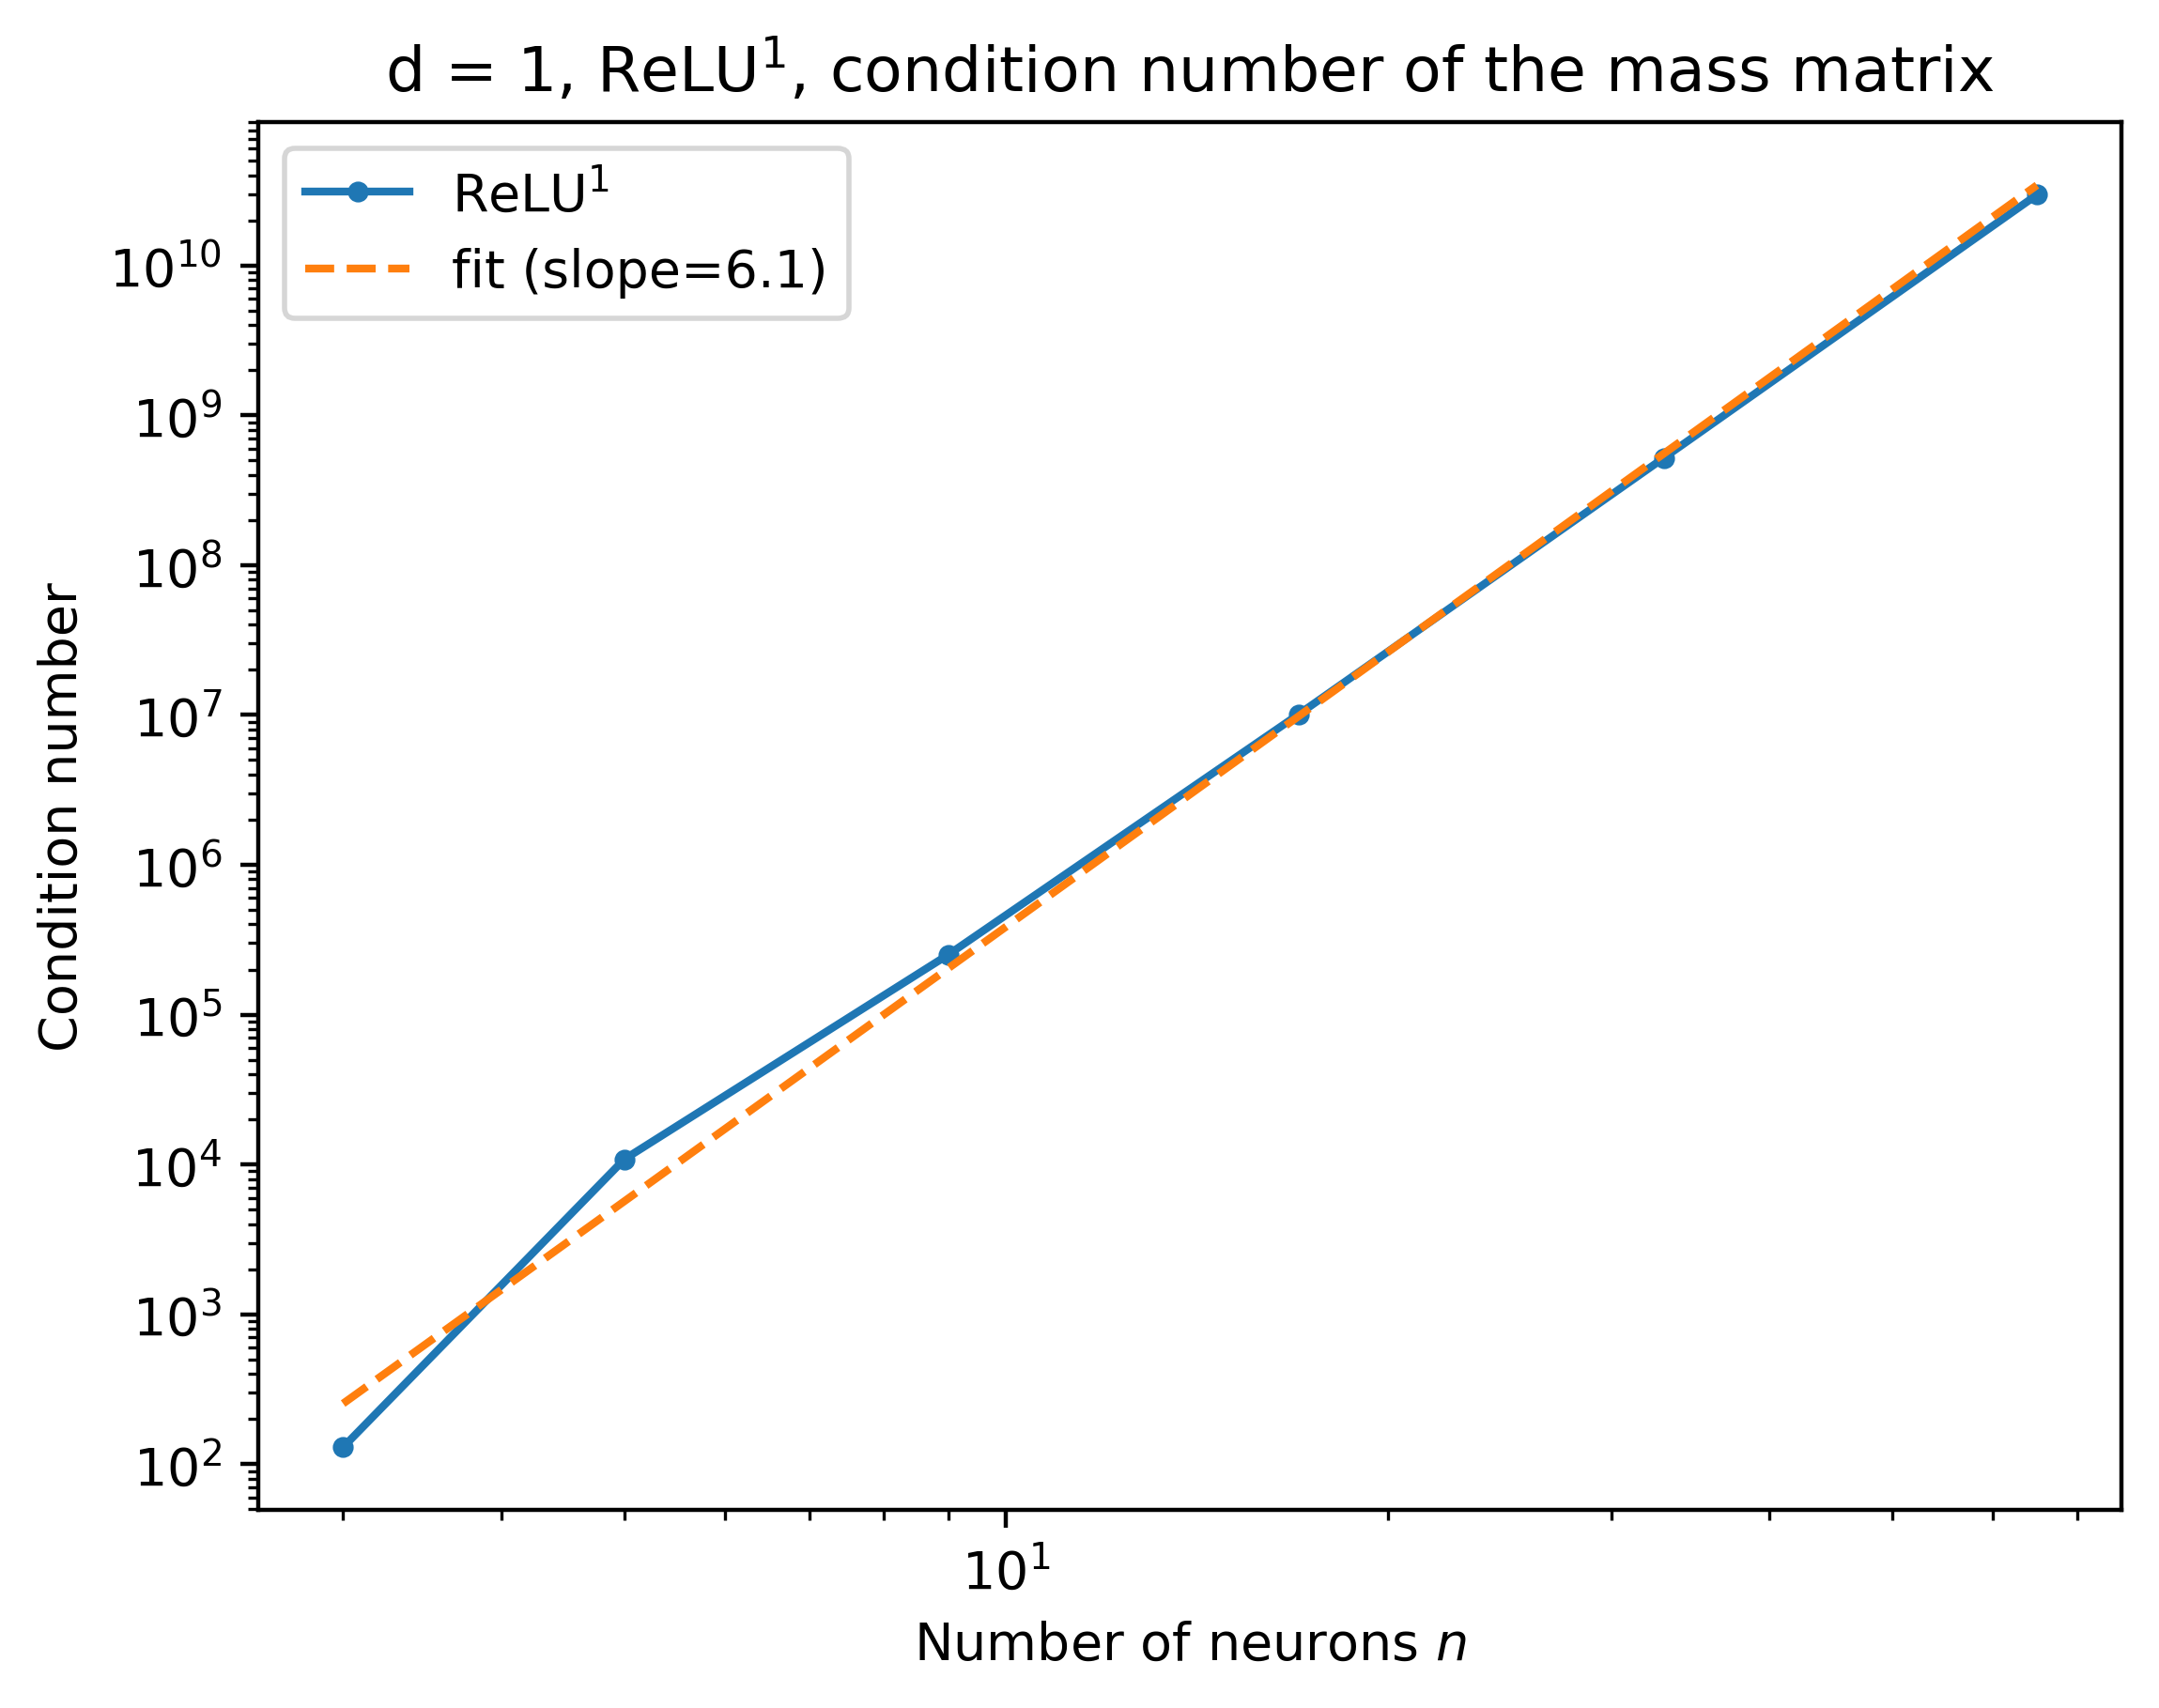

In [33]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])
    return z 


d = 1  
relu_k = 1  

Nx = 512   
order = 10   
x_l, x_r = -1, 1
integration_weights, integration_points = PiecewiseGQ1D_weights_points(x_l,x_r,Nx, order)
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(2,8)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
condition_number_list = [] 
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    # my_model = initialize_model_3(my_model).to(device)
    my_model = initialize_model_1d(my_model.cpu()).to(device)
    
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 

    Jac, rhs = assemble_linear_system_L2(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    condition_number = np.linalg.cond(np.array(Jac.detach().cpu())) 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    print("condition number: ", condition_number) 
    condition_number_list.append(condition_number) 

actual_neuron_arr = np.array(actual_neuron_list)
condition_number_arr = np.array(condition_number_list) 
plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k)


## 2D example  

Number of neurons removed:  2
Number of neurons left:  14
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.1353311538696289
condition number:  26830.54015534706
Number of neurons removed:  4
Number of neurons left:  28
num batch:  1


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_98142/2495193659.py:28: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  condition_number = np.linalg.cond(np.array(Jac.detach().cpu()))


jac:  cpu
assembling the matrix time taken:  0.3075079917907715
condition number:  64539573.4488328
Number of neurons removed:  12
Number of neurons left:  52
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.5513772964477539
condition number:  11564928.688451428
Number of neurons removed:  25
Number of neurons left:  103
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.956679105758667
condition number:  625296248.8886652
Number of neurons removed:  54
Number of neurons left:  202
num batch:  1
jac:  cpu
assembling the matrix time taken:  2.6770172119140625
condition number:  64149386482.62357
Number of neurons removed:  113
Number of neurons left:  399
num batch:  1
jac:  cpu
assembling the matrix time taken:  15.440533876419067
condition number:  368978616899.89966


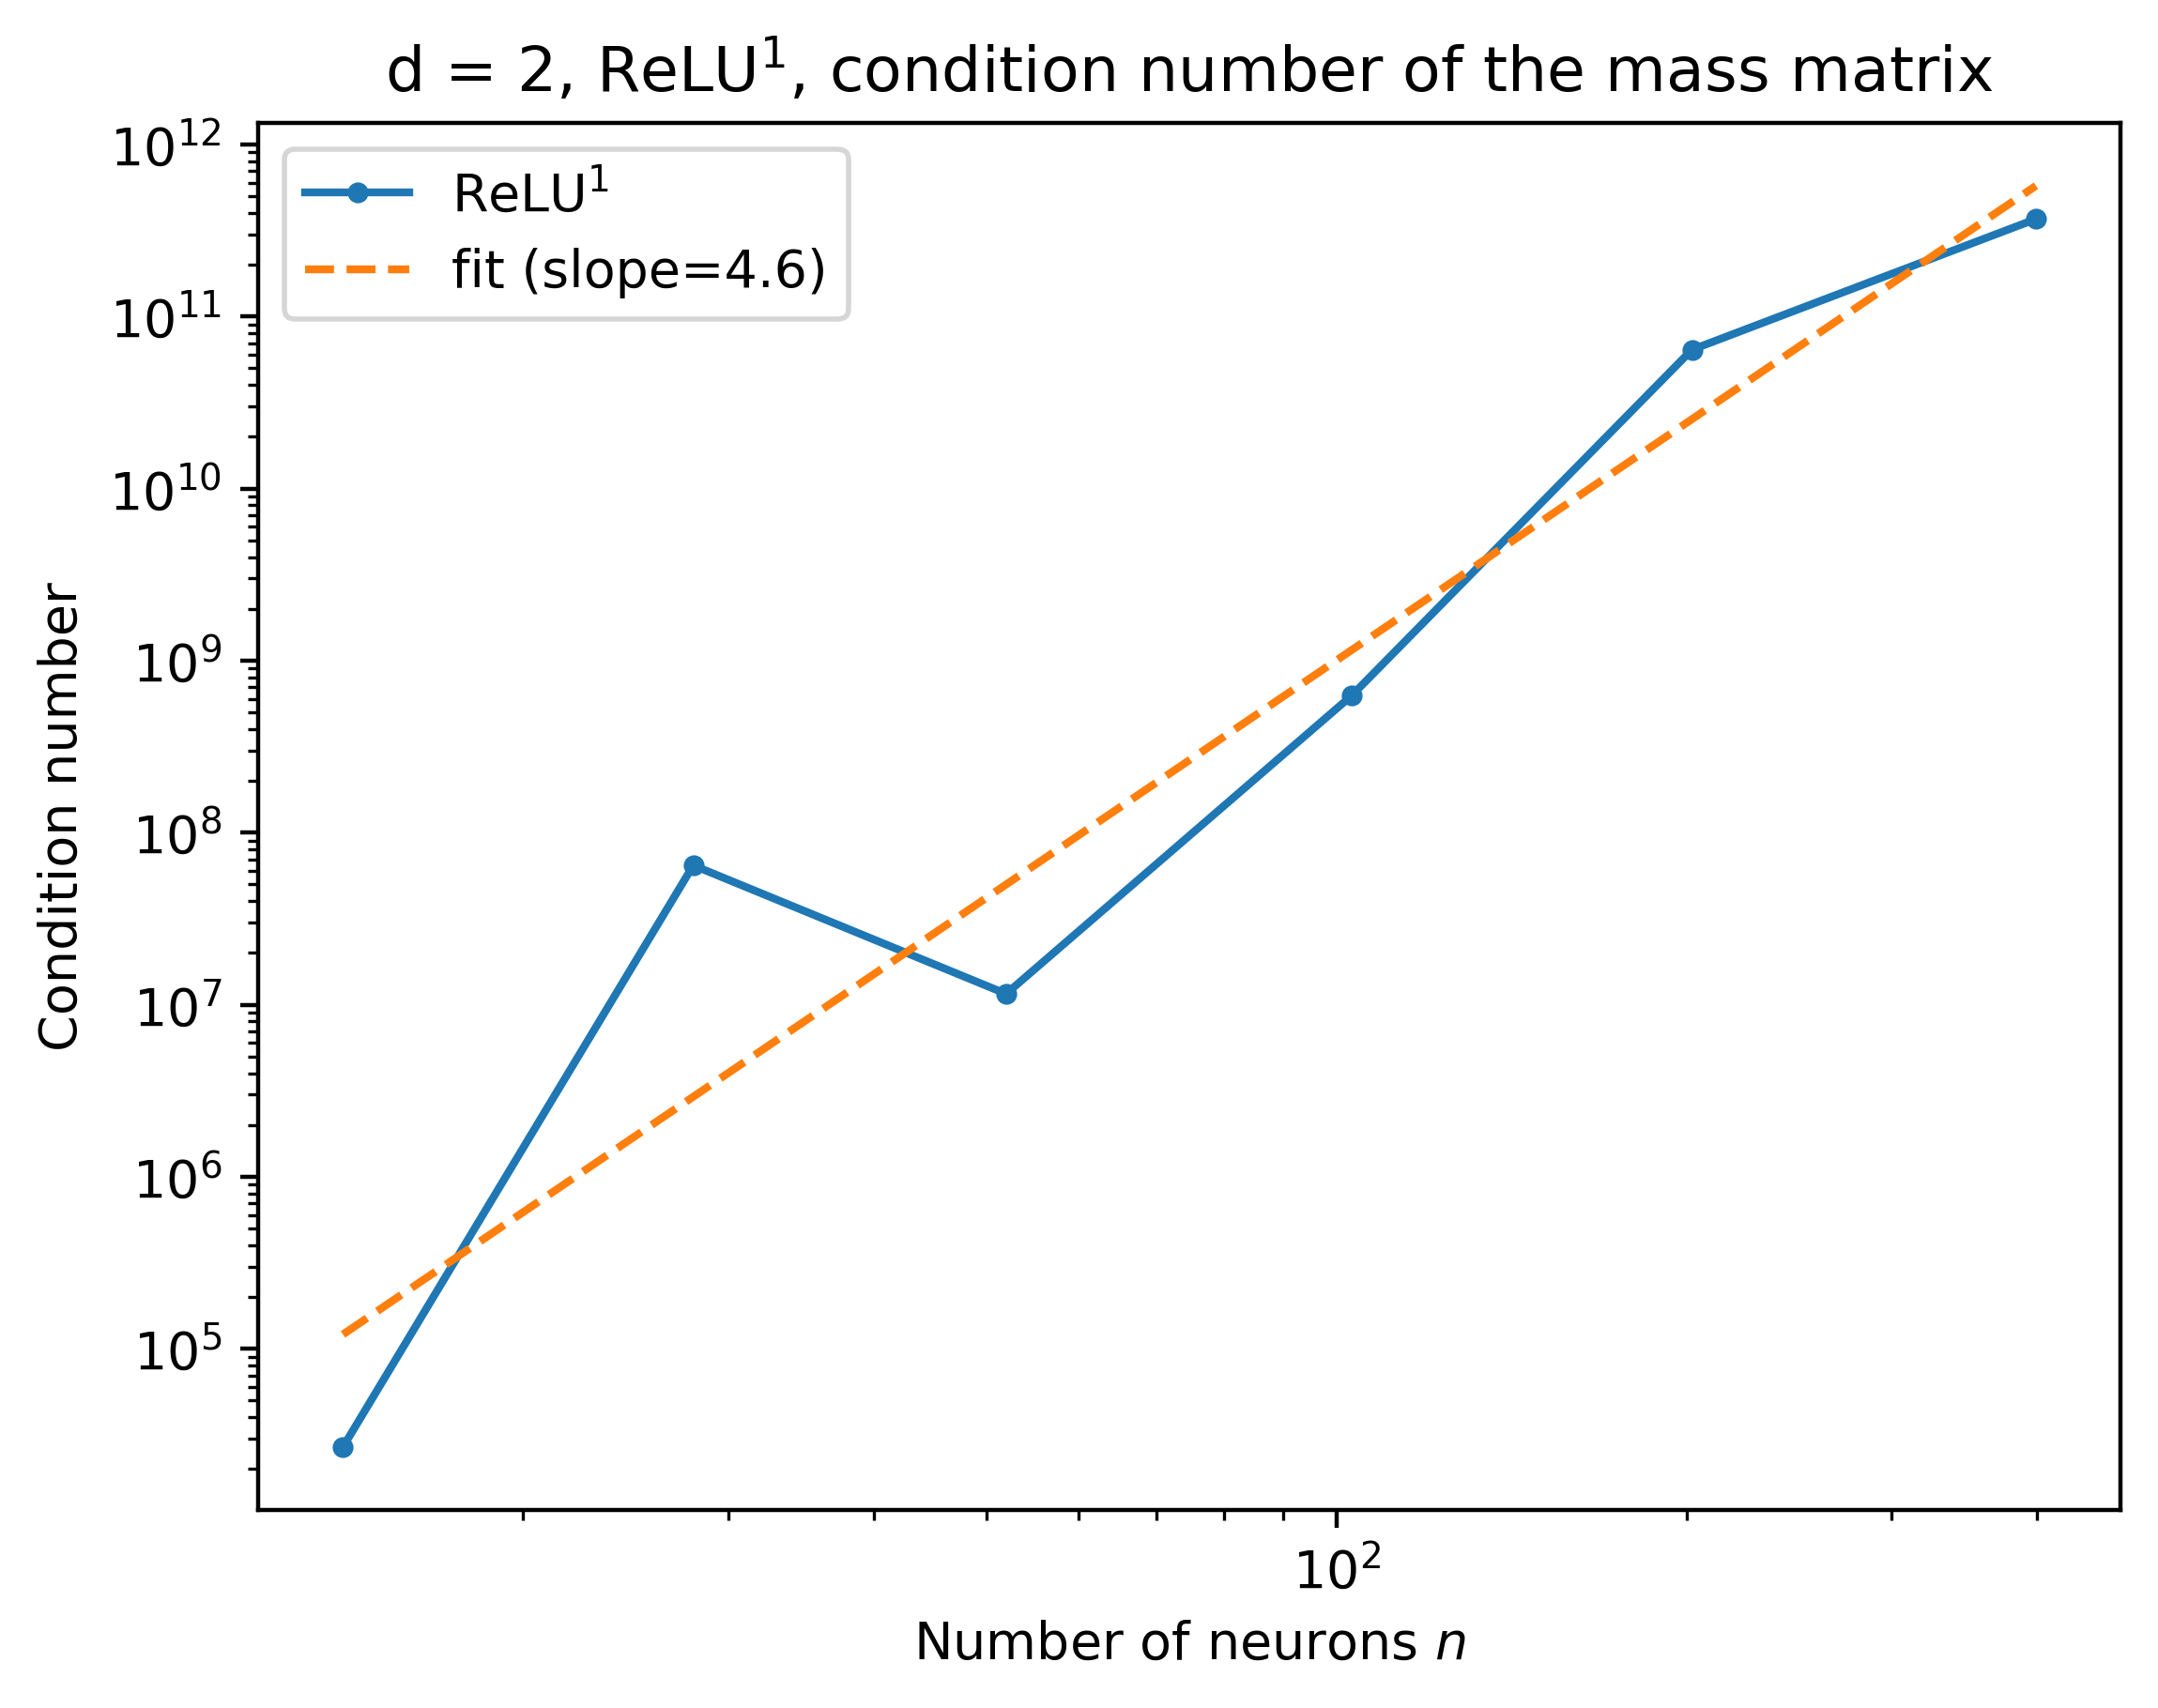

In [34]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])*torch.sin(m * pi*x[:,1:2] ) # * torch.sin(pi/2*x[:,2:3])  
    return z 


d = 2 
relu_k = 1   

Nx = 400  
order = 2 
integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx, order,[-1,-1],[1,1])
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(4,10)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
condition_number_list = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_3(my_model).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = 2, choice = 2).to(device) 


    Jac, rhs = assemble_linear_system_L2(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    condition_number = np.linalg.cond(np.array(Jac.detach().cpu())) 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    print("condition number: ", condition_number) 
    condition_number_list.append(condition_number) 

actual_neuron_arr = np.array(actual_neuron_list)
condition_number_arr = np.array(condition_number_list) 
plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k)



## 3D  example 

Number of neurons removed:  4
Number of neurons left:  12
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.3558011054992676
condition number:  1546.8894373954652
Number of neurons removed:  1
Number of neurons left:  31
num batch:  1


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_98142/1592039447.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  condition_number = np.linalg.cond(np.array(Jac.detach().cpu()))


jac:  cpu
assembling the matrix time taken:  2.3411831855773926
condition number:  826697.3930429075
Number of neurons removed:  3
Number of neurons left:  61
num batch:  1
jac:  cpu
assembling the matrix time taken:  8.739760875701904
condition number:  3958200495.127306
Number of neurons removed:  7
Number of neurons left:  121
num batch:  2
jac:  cpu
assembling the matrix time taken:  14.418150186538696
condition number:  562857238.6824777
Number of neurons removed:  23
Number of neurons left:  233
num batch:  3
jac:  cpu
assembling the matrix time taken:  39.92798733711243
condition number:  655059746032.129
Number of neurons removed:  47
Number of neurons left:  465
num batch:  6
jac:  cpu
assembling the matrix time taken:  130.15200400352478
condition number:  81173374599.23763


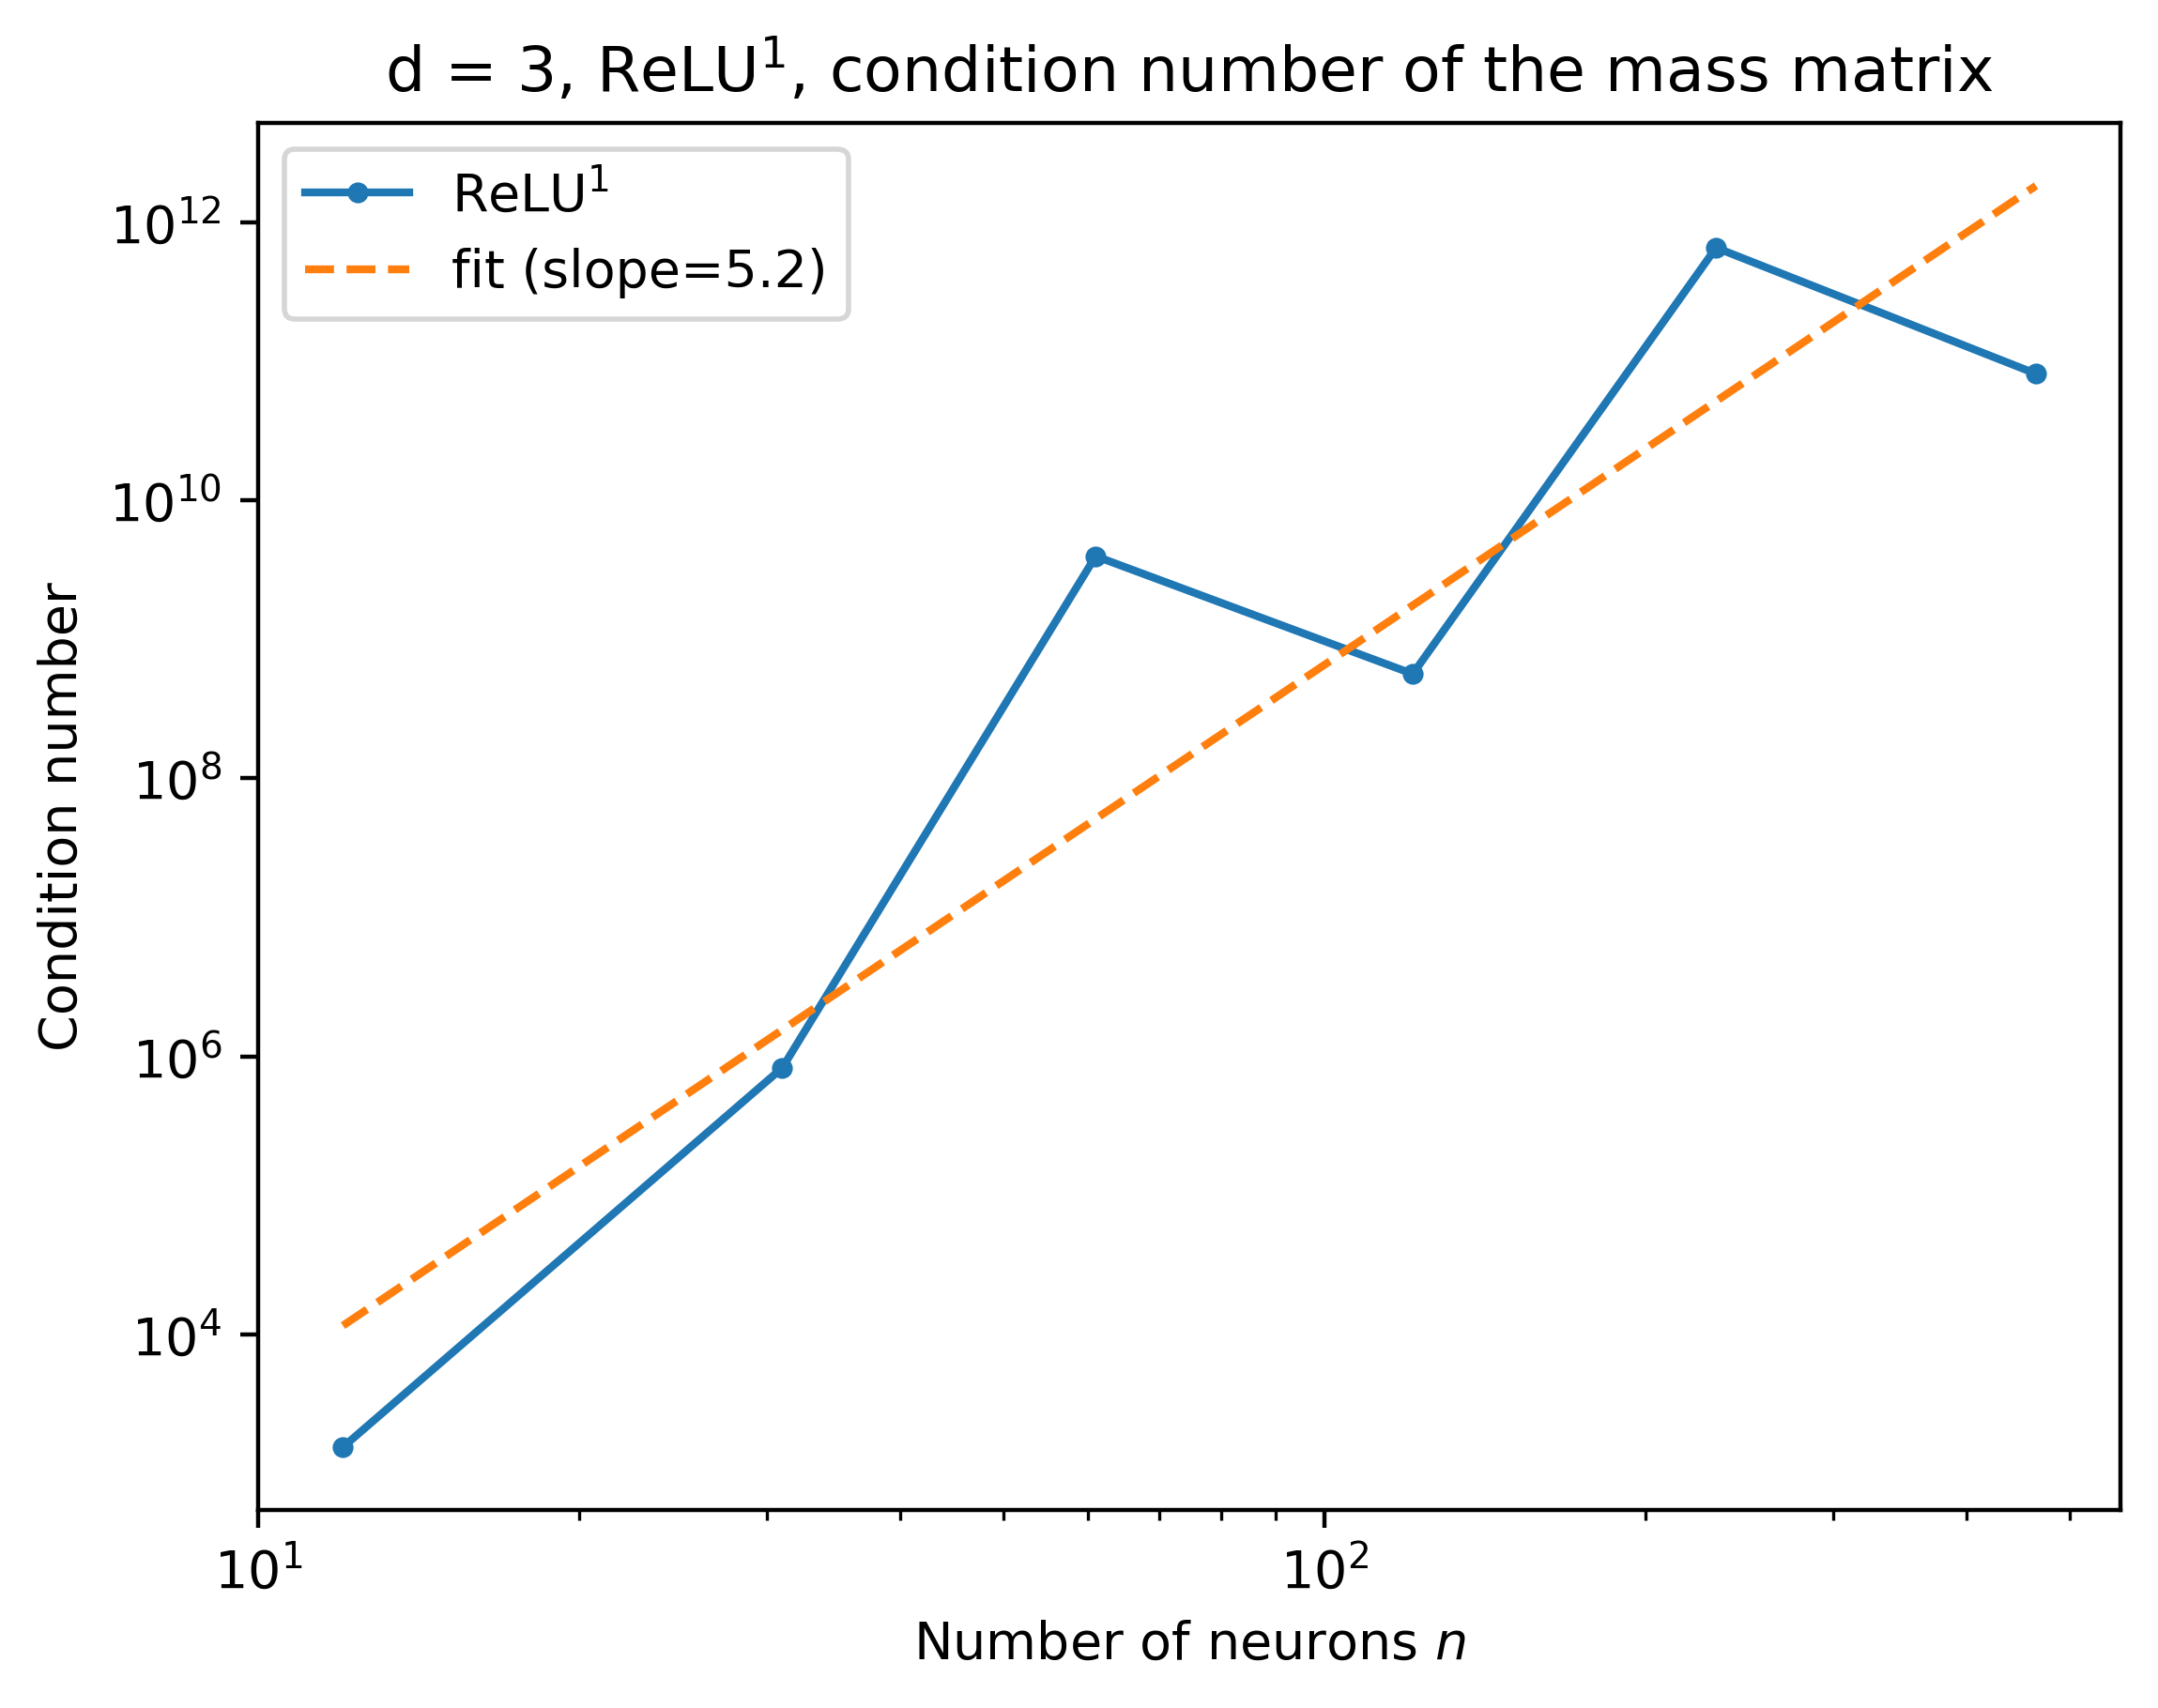

In [36]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])*torch.sin(m * pi*x[:,1:2] ) * torch.sin(m * pi*x[:,2:3])  
    return z 

d = 3 
relu_k = 1  

Nx = 50   
order = 3 
integration_weights, integration_points = PiecewiseGQ3D_weights_points(Nx, order,[-1,-1,-1],[1,1,1])
M = integration_points.size(0)
# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(4,10)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
condition_number_list = [] 
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 

    Jac, rhs = assemble_linear_system_L2(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    condition_number = np.linalg.cond(np.array(Jac.detach().cpu())) 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    print("condition number: ", condition_number) 
    condition_number_list.append(condition_number) 

actual_neuron_arr = np.array(actual_neuron_list)
condition_number_arr = np.array(condition_number_list) 
plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k)


## 4D example 

Number of neurons removed:  0
Number of neurons left:  16
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.08619976043701172
condition number:  5050.225894106166
Number of neurons removed:  1
Number of neurons left:  31
num batch:  1


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_98142/1002621554.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  condition_number = np.linalg.cond(np.array(Jac.detach().cpu()))


jac:  cpu
assembling the matrix time taken:  0.20155596733093262
condition number:  17849571.014620826
Number of neurons removed:  0
Number of neurons left:  64
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.2877039909362793
condition number:  259810.27401194235
Number of neurons removed:  1
Number of neurons left:  127
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.6660299301147461
condition number:  18370811590.407654
Number of neurons removed:  4
Number of neurons left:  252
num batch:  1
jac:  cpu
assembling the matrix time taken:  2.907454252243042
condition number:  3463930080.0995116
Number of neurons removed:  12
Number of neurons left:  500
num batch:  1
jac:  cpu
assembling the matrix time taken:  51.72611403465271
condition number:  133197264371.48378


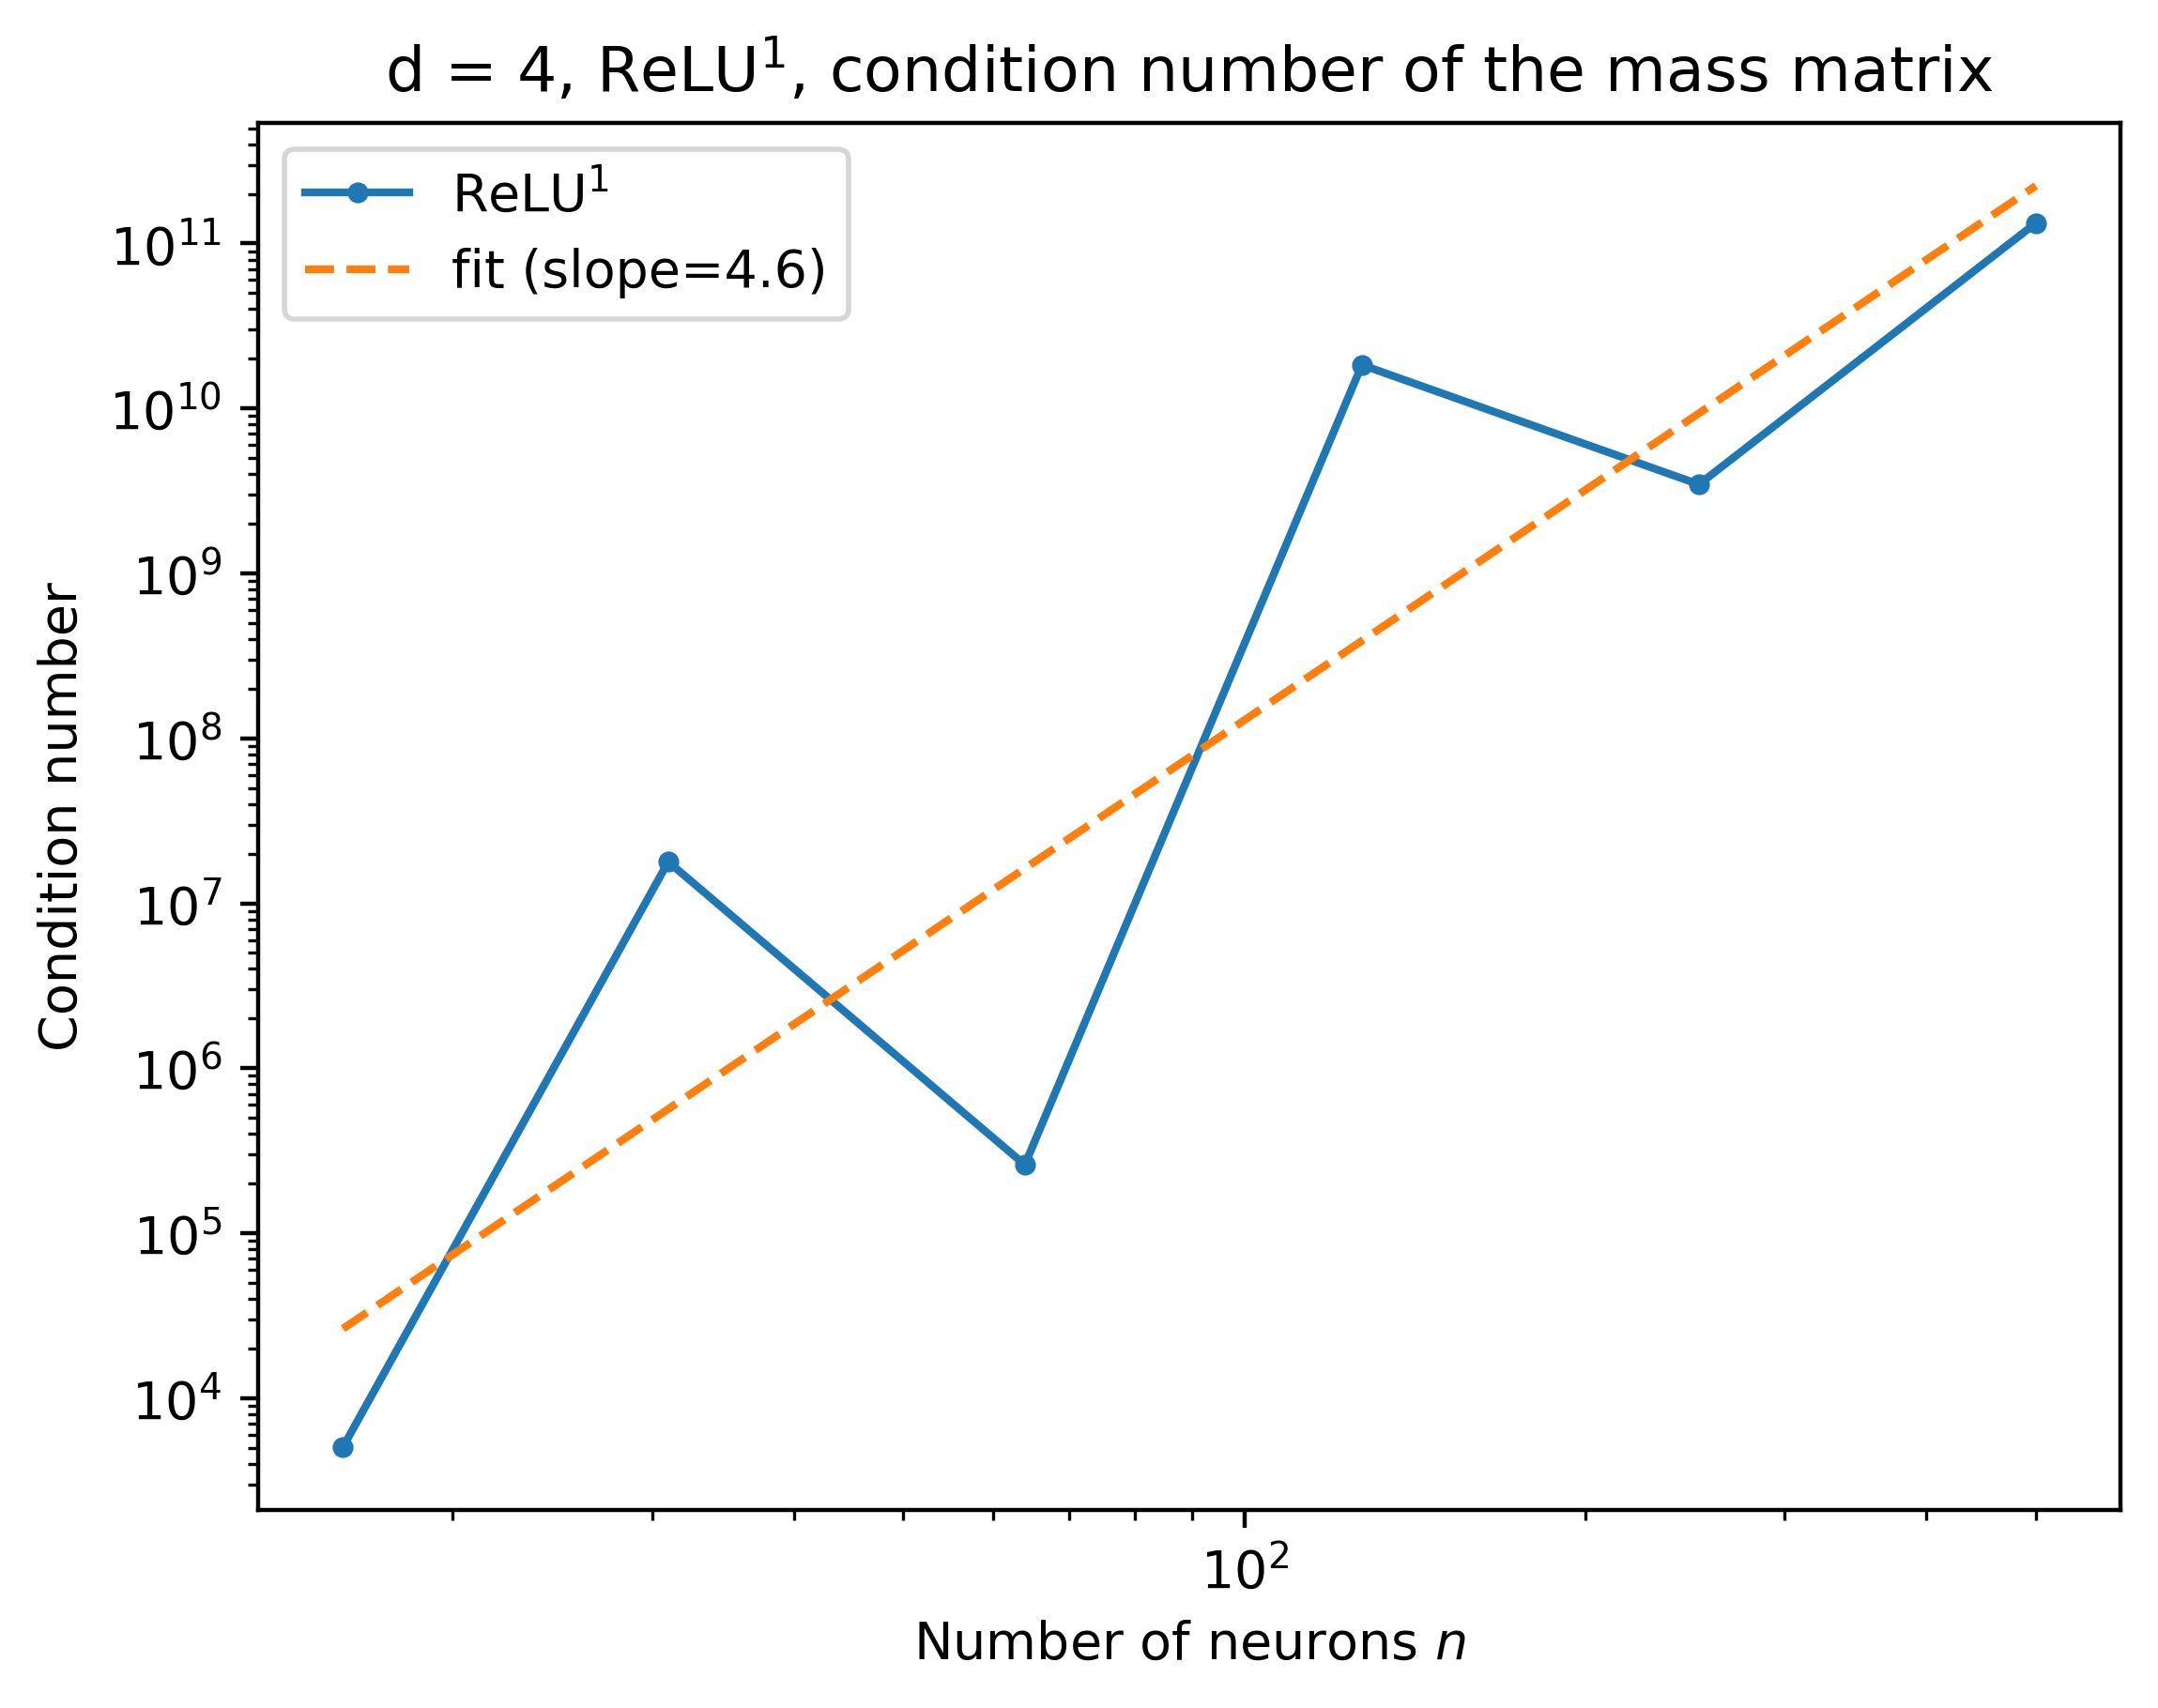

In [37]:
##1. exact solution: sin(pi/2 x)sin(pi/2 y) 
m = 1/2 
def u_exact(x): 
    z = torch.sin(m * pi*x[:,0:1])*torch.sin(m * pi*x[:,1:2] ) * torch.sin(m * pi*x[:,2:3]) * torch.sin(m*pi*x[:,3:4])   
    return z 


d = 4 
relu_k = 1 


M = int(8e5)
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M ,d = d,bl = -1,ur = 1)
neuron_num_arr= np.array([2**i for i in range(4,10)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
condition_number_list = []
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 

    Jac, rhs = assemble_linear_system_L2(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**29)
    condition_number = np.linalg.cond(np.array(Jac.detach().cpu())) 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    print("condition number: ", condition_number) 
    condition_number_list.append(condition_number) 

actual_neuron_arr = np.array(actual_neuron_list)
condition_number_arr = np.array(condition_number_list) 
plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k)



Number of neurons removed:  0
Number of neurons left:  16
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.08945608139038086
condition number:  52615.68908167669
Number of neurons removed:  0
Number of neurons left:  32
num batch:  1


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_98142/1295279941.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  condition_number = np.linalg.cond(np.array(Jac.detach().cpu()))


jac:  cpu
assembling the matrix time taken:  0.16187500953674316
condition number:  43436.177124325906
Number of neurons removed:  0
Number of neurons left:  64
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.24789881706237793
condition number:  7174413895.661389
Number of neurons removed:  2
Number of neurons left:  126
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.5767452716827393
condition number:  43422769.61136801
Number of neurons removed:  2
Number of neurons left:  254
num batch:  1
jac:  cpu
assembling the matrix time taken:  1.4890360832214355
condition number:  4017467.7216800693
Number of neurons removed:  2
Number of neurons left:  510
num batch:  1
jac:  cpu
assembling the matrix time taken:  45.40705680847168
condition number:  4.3126313510082655e+21


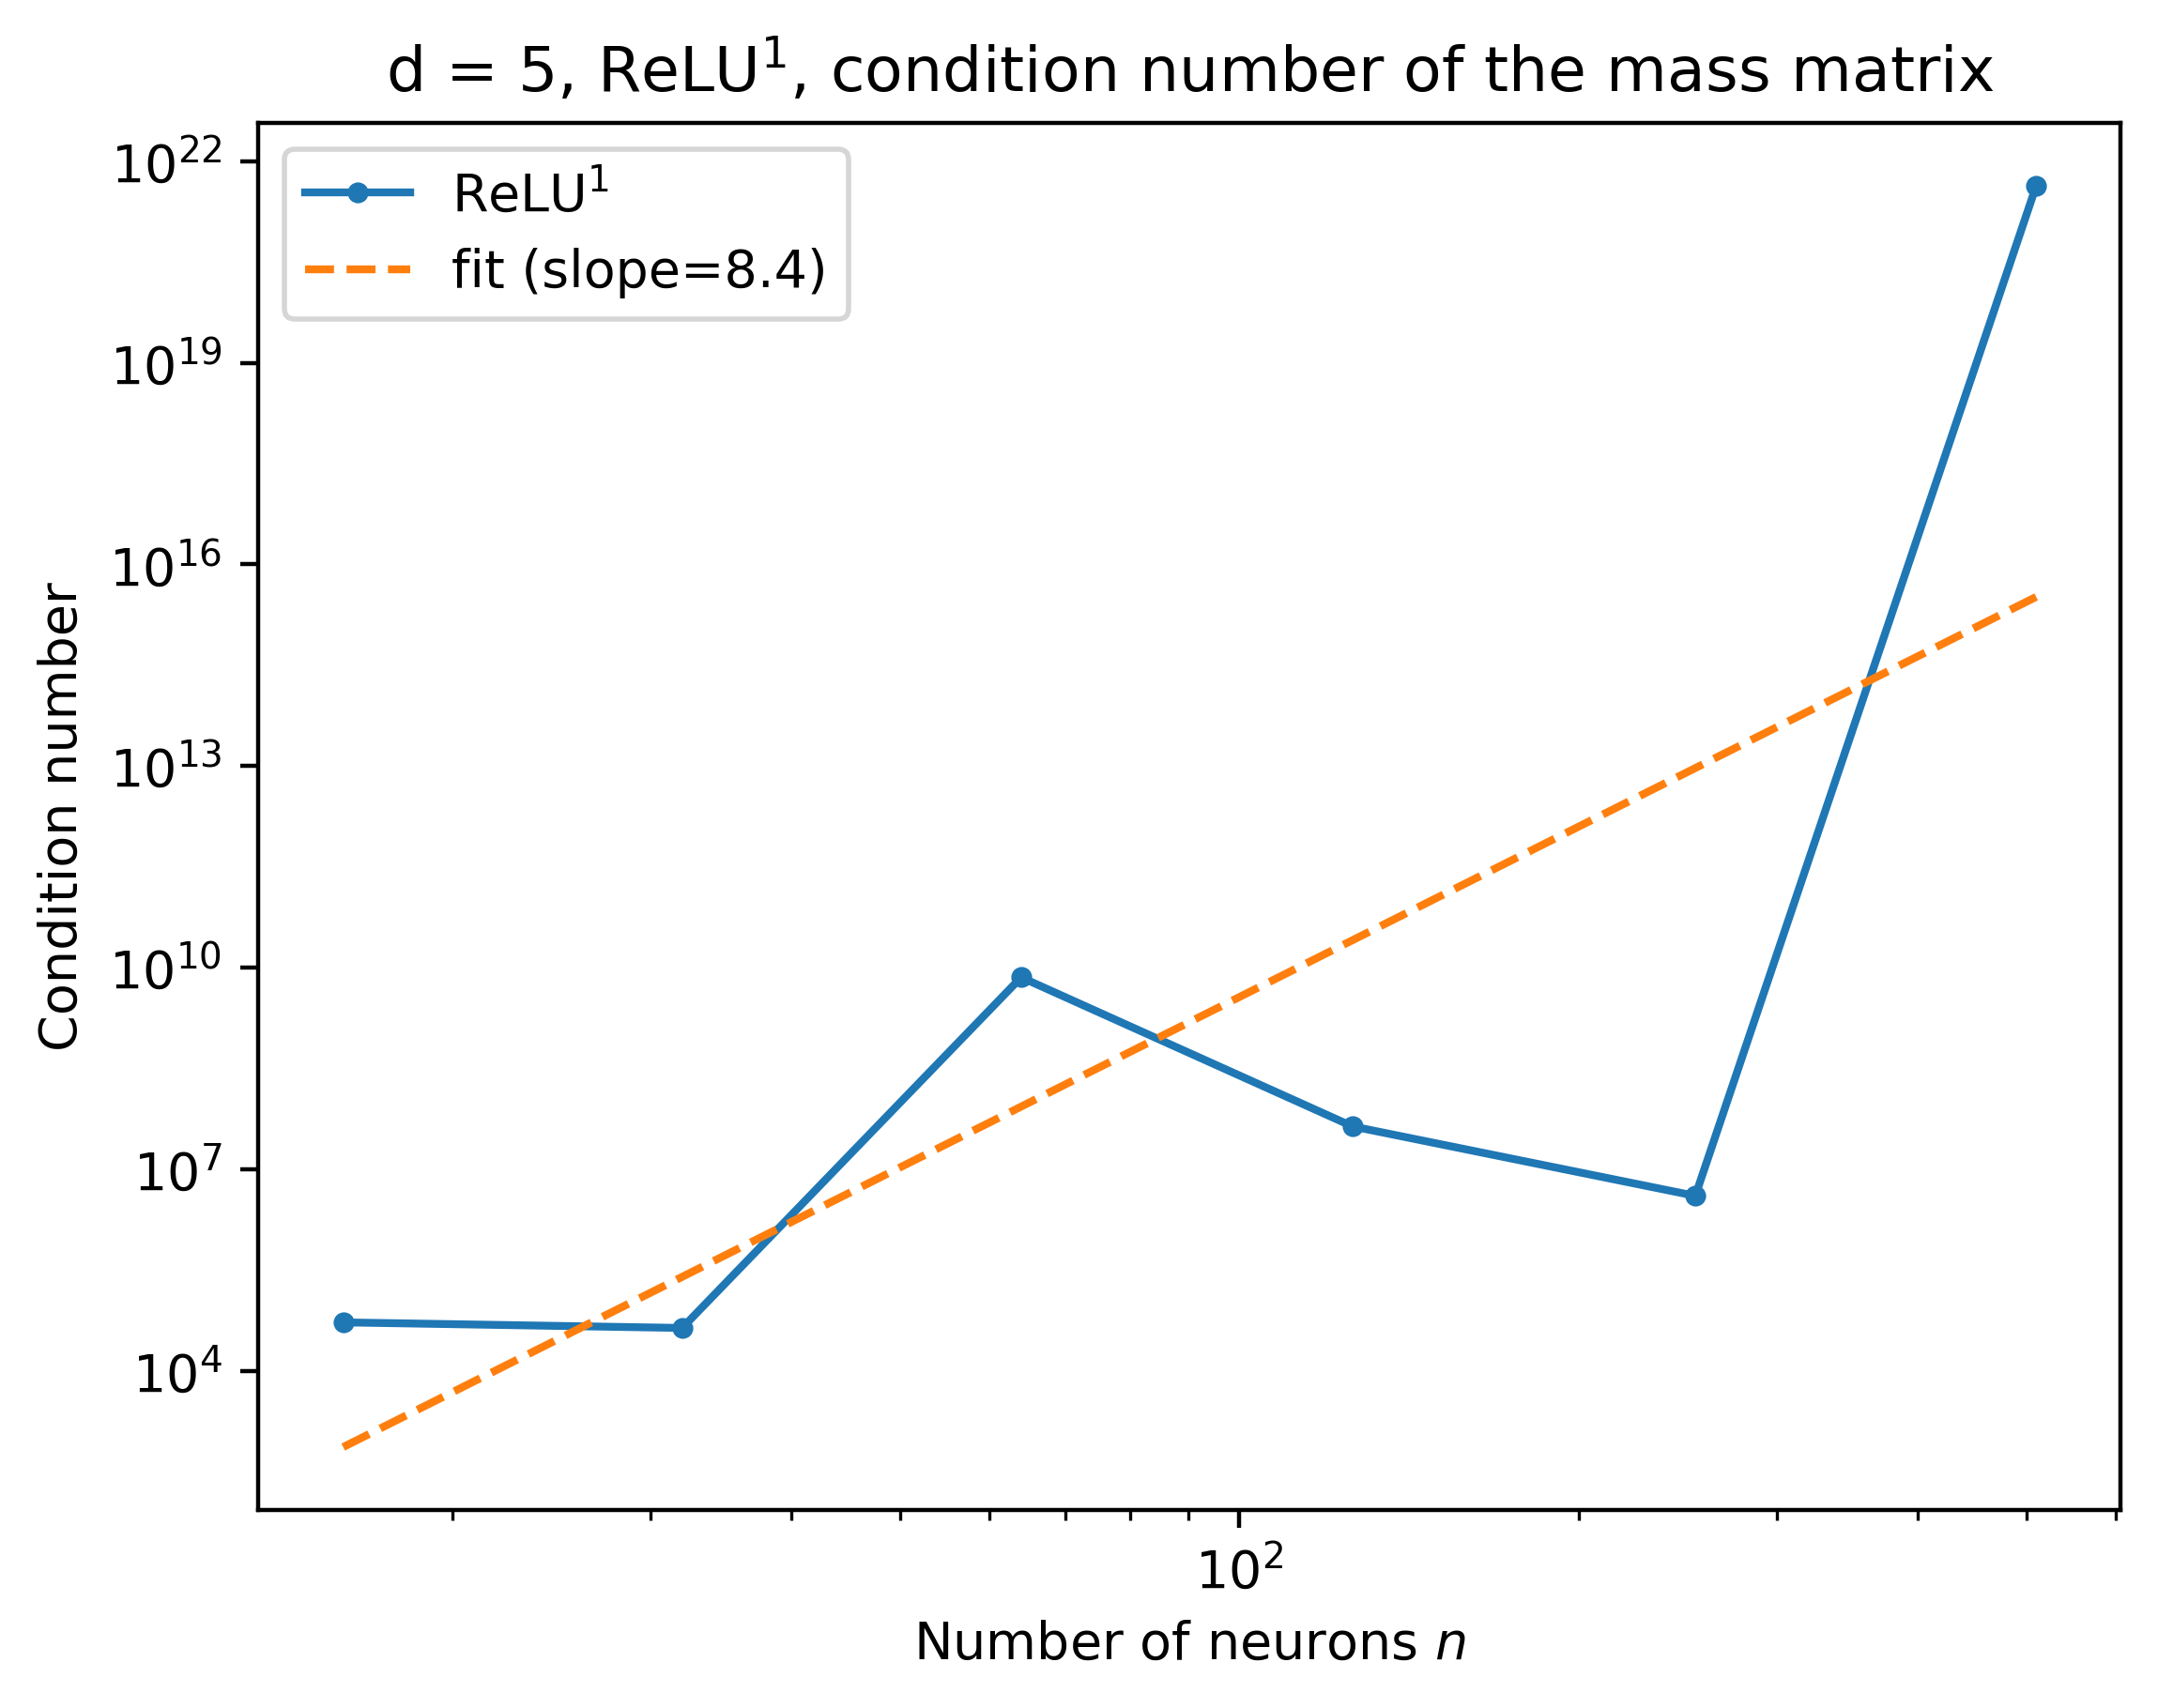

In [38]:






m = 1/2 
def u_exact(x):
    z = torch.prod(torch.sin(m * pi * x),dim = 1,keepdim = True)
    return z 

d = 5 
relu_k = 1  

M = int(8e5)
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M ,d = d,bl = -1,ur = 1)

# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(4,10)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
condition_number_list = [] 
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 

    Jac, rhs = assemble_linear_system_L2(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**29)
    condition_number = np.linalg.cond(np.array(Jac.detach().cpu())) 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    print("condition number: ", condition_number) 
    condition_number_list.append(condition_number) 

actual_neuron_arr = np.array(actual_neuron_list)
condition_number_arr = np.array(condition_number_list) 
plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k)


Number of neurons removed:  0
Number of neurons left:  16
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.10789895057678223
condition number:  190951.561539434
Number of neurons removed:  0
Number of neurons left:  32
num batch:  1


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_98142/3515720512.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  condition_number = np.linalg.cond(np.array(Jac.detach().cpu()))


jac:  cpu
assembling the matrix time taken:  0.19542884826660156
condition number:  1400141.2897822596
Number of neurons removed:  0
Number of neurons left:  64
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.30724191665649414
condition number:  16499.22134791743
Number of neurons removed:  0
Number of neurons left:  128
num batch:  1
jac:  cpu
assembling the matrix time taken:  0.6620869636535645
condition number:  34797007.84763252
Number of neurons removed:  0
Number of neurons left:  256
num batch:  1
jac:  cpu
assembling the matrix time taken:  3.5335471630096436
condition number:  2483368.5249313284
Number of neurons removed:  0
Number of neurons left:  512
num batch:  1
jac:  cpu
assembling the matrix time taken:  90.07885479927063
condition number:  3.6644834477271574e+20


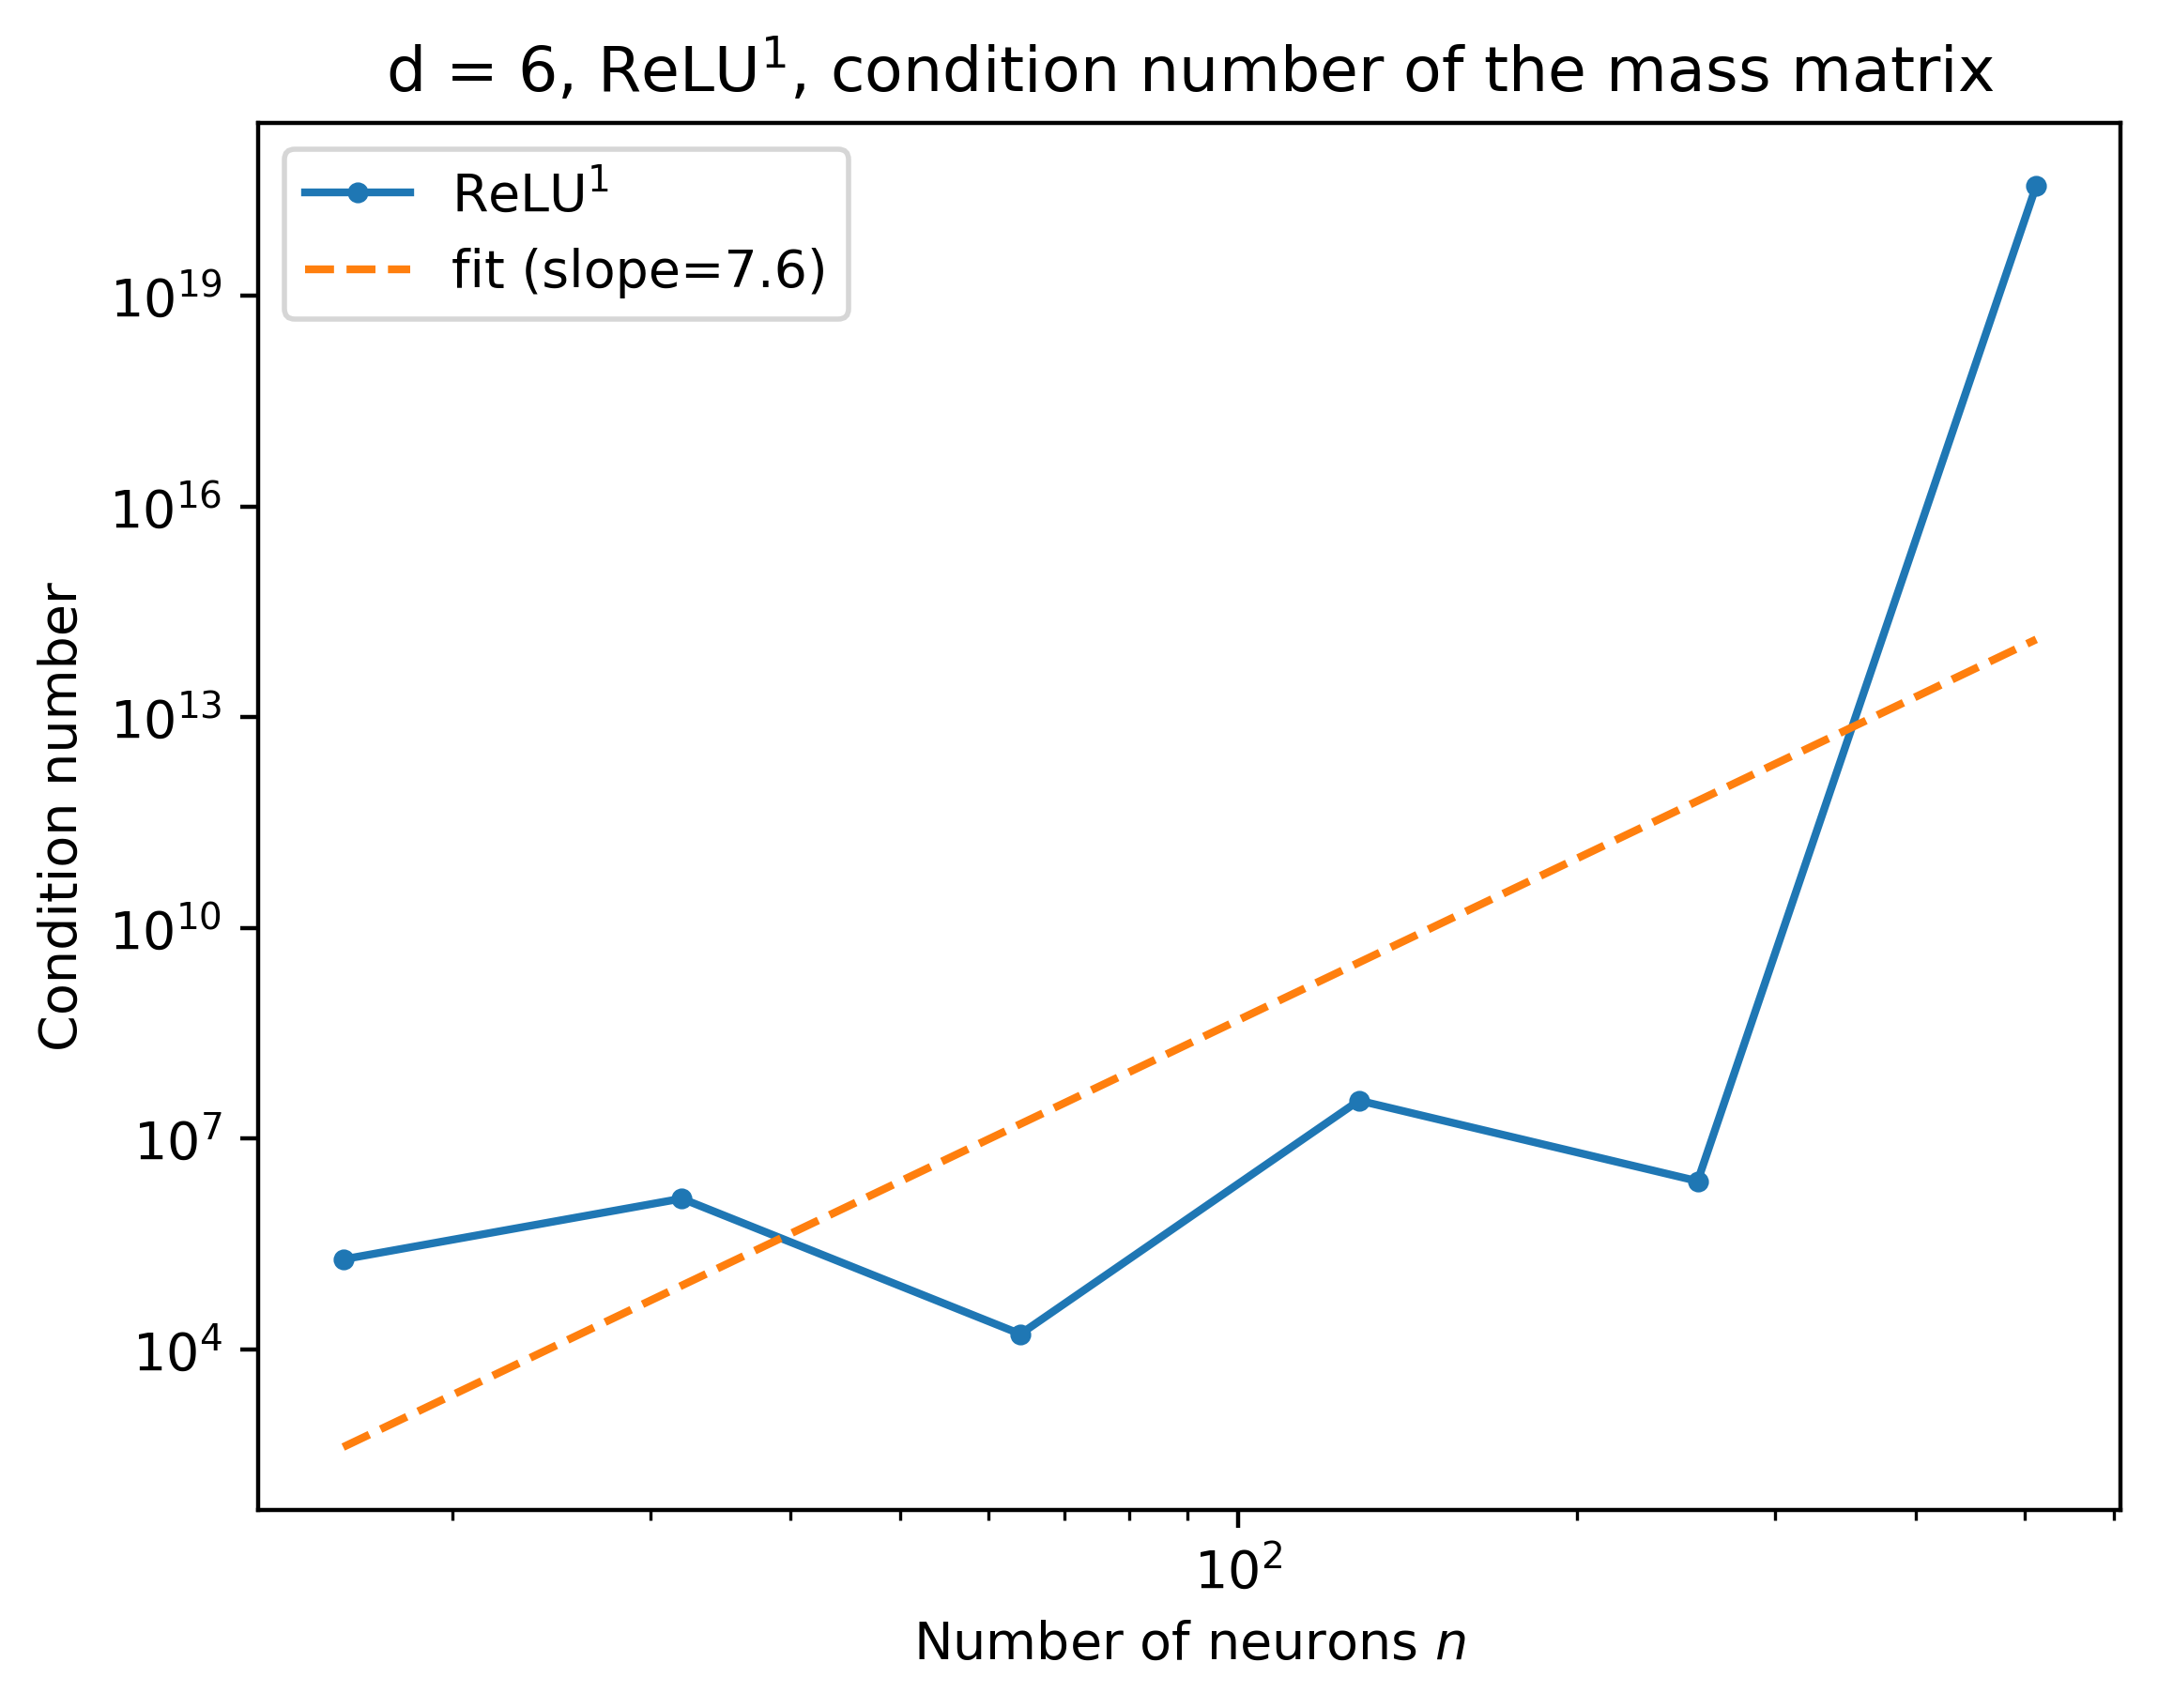

In [39]:






m = 1/2 
def u_exact(x):
    z = torch.prod(torch.sin(m * pi * x),dim = 1,keepdim = True)
    return z 

d = 6 
relu_k = 1 

M = int(1e6)
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M ,d = d,bl = -1,ur = 1)

# neuron_num_list = [25,50,100,200,400,800,1600]
neuron_num_arr= np.array([2**i for i in range(4,10)]) 
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
condition_number_list = [] 
for neuron_num in neuron_num_arr: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 

    Jac, rhs = assemble_linear_system_L2(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**29)
    condition_number = np.linalg.cond(np.array(Jac.detach().cpu())) 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 
    print("condition number: ", condition_number) 
    condition_number_list.append(condition_number) 

actual_neuron_arr = np.array(actual_neuron_list)
condition_number_arr = np.array(condition_number_list) 
plot_condition_numbers(actual_neuron_arr, condition_number_arr, d, relu_k)


In [64]:
d = 6 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.0833333333333335
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
25 		 & 9.984e-01 &		 *  \\ \hline  

50 		 &  9.994e-01 &  		 -0.00  \\ \hline  

99 		 &  9.974e-01 &  		 0.00  \\ \hline  

200 		 &  9.695e-01 &  		 0.04  \\ \hline  

400 		 &  7.864e-01 &  		 0.30  \\ \hline  

799 		 &  3.846e-01 &  		 1.03  \\ \hline  

1597 		 &  1.577e-01 &  		 1.29  \\ \hline  

3195 		 &  7.152e-02 &  		 1.14  \\ \hline  



In [75]:
d = 6 
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)

M = int(5e7) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, d, -1, 1) 
neuron_num_list = [25,50,100,200,400,800,1600]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 3 
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_2(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())

Number of neurons removed:  0
Number of neurons left:  25
num batch:  5
jac:  cuda:0
assembling the matrix time taken:  0.001644134521484375
solving Ax = b time taken:  0.09284496307373047
L2 error:  tensor(0.9678, device='cuda:0')
Number of neurons removed:  2
Number of neurons left:  48
num batch:  9
jac:  cuda:0
assembling the matrix time taken:  0.002453327178955078
solving Ax = b time taken:  0.14238691329956055
L2 error:  tensor(0.4142, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  100
num batch:  19
jac:  cuda:0
assembling the matrix time taken:  0.00417637825012207
solving Ax = b time taken:  0.33310437202453613
L2 error:  tensor(0.2105, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  200
num batch:  38
jac:  cuda:0
assembling the matrix time taken:  0.007967948913574219
solving Ax = b time taken:  0.7835638523101807
L2 error:  tensor(0.0728, device='cuda:0')
Number of neurons removed:  0
Number of neurons left:  400
num batch: 

In [76]:
d = 6 
print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
output_convergence_order_l2(actual_neuron_list,err_list_l2)

L2 order: 1.0833333333333335
$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
25 		 & 9.678e-01 &		 *  \\ \hline  

48 		 &  4.142e-01 &  		 1.30  \\ \hline  

100 		 &  2.105e-01 &  		 0.92  \\ \hline  

200 		 &  7.277e-02 &  		 1.53  \\ \hline  

400 		 &  9.118e-03 &  		 3.00  \\ \hline  

800 		 &  2.598e-03 &  		 1.81  \\ \hline  

1597 		 &  6.774e-04 &  		 1.94  \\ \hline  



In [4]:
def remove_redundant_neuron(my_model, dims = 3, choice = 2): 
    ##  choice 1:  [0,1]^d, choice 2: [-1,1]^d
    def create_mesh_grid(dims, pts):
        mesh = torch.tensor(list(itertools.product(pts,repeat=dims)))
        vertices = mesh.reshape(len(pts) ** dims, -1) 
        return vertices
    counter = 0 
    # positions = torch.tensor([[0.,0.],[0.,1.],[1.,1.],[1.,0.]])
    # pts = torch.tensor([0.,1.]) # for domain [0,1]^d 
    if choice == 1: 
        pts = torch.tensor([0.,1.])
    elif choice == 2:
        pts = torch.tensor([-1.,1.])# for domain [-1,1]^d 
    elif choice == 3:
        pts = torch.tensor([-1./2,1./2])# for domain [-1,1]^d 
    positions = create_mesh_grid(dims,pts) 
    neuron_num = my_model.fc1.bias.size(0)
    relu_k = my_model.k 
    recorded_neurons = []
    poly_dofs = math.comb(relu_k + dims, dims)
    for i in range(neuron_num): 
        w = my_model.fc1.weight.data[i:i+1,:]
        b = my_model.fc1.bias.data[i]
        values = torch.matmul(positions,w.T)
        left_end = - torch.max(values)
        right_end = - torch.min(values)
        offset = (right_end - left_end)/20 #50 
        if b > left_end + offset/2 and b < right_end - offset/2: 
            recorded_neurons.append((w, b))
        elif b >= right_end - offset/2 and counter < poly_dofs:
            recorded_neurons.append((w, b))
            counter += 1

    new_neuron_num = len(recorded_neurons)
    new_model = model(dims, new_neuron_num, 1, k=relu_k).to(device)
    for i, (w, b) in enumerate(recorded_neurons):
        new_model.fc1.weight.data[i:i+1,:] = w
        new_model.fc1.bias.data[i] = b
    print("Number of neurons removed: ", neuron_num - new_neuron_num)
    print("Number of neurons left: ", new_neuron_num)  
    return new_model


def initialize_model_4(my_model,dim = 2):
    # (w,b) ~ U(S^2)
    neuron_nums = my_model.fc1.bias.size(0)
#     points = torch.randn(neuron_nums,dim + 1)
#     points = points/torch.norm(points, dim=1, keepdim=True)
    my_model.fc1.weight.data[:,:] = torch.ones(neuron_nums,dim)/(dim)  # points[:,0:dim]
    
#     biases = torch.linspace(0,1,neuron_nums)* 4 * dim **0.5 -  2  * dim **0.5
    biases = torch.linspace(0,1,neuron_nums)* 2 * dim **0.5 -  1 * dim **0.5
    my_model.fc1.bias.data[:] = biases[:]  
    return my_model 

d = 6 
def u_exact(x):
    d = x.size(1)
    # x: (N, d+1) with the last column being t
    s = x[:, :d].sum(dim=1, keepdim=True) / d
    # t = x[:, -1:]
    return torch.sin(s)  # * torch.exp(-t / d)


M = int(1e8) 
integration_weights, integration_points = MonteCarlo_Sobol_dDim_weights_points(M, d, -1, 1) 
neuron_num_list = [6,12,25,50,100,200]
actual_neuron_list = []
err_list_l2 = []
err_list_h1 = []
relu_k = 1
for neuron_num in neuron_num_list: 
    my_model = model(d,neuron_num,1,relu_k).to(device)
    my_model = initialize_model_4(my_model,dim=d).to(device)
    my_model = remove_redundant_neuron(my_model.cpu(), dims = d, choice = 2).to(device) 
    solver = 'direct'
    sol = minimize_linear_layer_explicit_assemble(my_model,u_exact,integration_weights, integration_points,solver="direct",memory=2**28)
    my_model.fc2.weight.data[0,:] = sol[:] 
    actual_neuron_list.append(my_model.fc1.bias.size(0)) 

    # compute the error 
    memory = 2**28 
    num_neuron = 0 if my_model == None else int(my_model.fc1.bias.detach().data.size(0))
    total_size2 = M*(num_neuron+1)
    num_batch2 = total_size2//memory + 1 
    batch_size_2 = M//num_batch2 #
    errl2 = compute_l2_error(u_exact,my_model,M,batch_size_2,integration_weights,integration_points)
    
    print("L2 error: ",errl2)
    err_list_l2.append(errl2.item())

print("L2 order:",0.5 + (2*relu_k +1)/(2*d))
# print("H1 order:",0.5 + (2*(relu_k-1) +1)/(2*d))

output_convergence_order_l2(actual_neuron_list,err_list_l2)

OutOfMemoryError: CUDA out of memory. Tried to allocate 4.47 GiB. GPU 0 has a total capacity of 79.25 GiB of which 283.44 MiB is free. Including non-PyTorch memory, this process has 4.88 GiB memory in use. Process 4022168 has 74.08 GiB memory in use. Of the allocated memory 4.47 GiB is allocated by PyTorch, and 2.00 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)